# Lab 2

## Overview 

In this problem set, you will demonstrate both your qualitative and quantitative understanding of this week's course material and use Python to explore the atmospheric general circulation. You will use the ERA5 atmopsheric reanalysis product produced by the Copernicus Climate Change Service at the European Centre for Medium-Range Weather Forecasts (ECMWF). The reanalysis combines model data with observations from around the world to provide hourly estimates of a large number of atmospheric, land, and oceanic climate variables. The data was accessed from the [ECMWF Climate Data Portal](https://www.ecmwf.int/en/forecasts/dataset/ecmwf-reanalysis-v5).

To foster a collaborative learning environment, you will complete this lab with a partner. The pairings will be randomly determined in class and posted on Canvas. Each person is required to complete and contribute to all questions. This includes performing all calculations/analyses and writing your own code. *It is against the honor code to divide up the questions among different individuals or use generative AI/chatbots on any aspect this assignment. All answers must be written in your own words.* All figures will be generated in this Jupyter Notebook. Please use comments (`#`) to organize your code and make it more readable.**This lab is worth 75 points.**

### Learning Outcomes
The goal of this is assignment is to demonstrate your understanding of fluid motion in a rotating reference frame and the atmopsheric general circulation. By completing this lab you will: 
- Articulate how meridional radiation imbalances set the atmopshere into motion and yield the atmospheric general circulation
- Describe the fundamental accelerations that determine horizontal and vertical winds 
- Manipulate gridded atmospheric reanalysis data using the Python Xarray package and perform statistical analyses
- Generate high-quality maps of long-term and seasonal mean atmospheric data using Cartopy, Matplotlib and cmocean
- Develop a set of sample code that you can later build upon for your final project.

### Canvas Submission
1. Work closely with your partner to ensure your answers reflect your joint understanding of the material. Collectively, write your responses to the short-answer questions in a Microsoft Word or shared Google document. Include all relevant figures. 

2. Run all Jupyter Notebooks from the beginning to confirm that all figures generate correctly and that there are no error messages. All individuals must upload their own Jupyter Notebook. Please name your notebooks as: *LastName_FirstName_EV333_Lab2.ipynb* and upload your files to Canvas (1 submission *per person*). ***There will be an automatic 10% deduction to your individual grade (not your partners) if your Jupyter notebook is missing.***

3. Decide which person's Notebook you would like to be graded and note this at the top of your lab write-up or as a comment in Canvas. Export your final document as a PDF and upload it to Canvas (1 submission per group).

Out of fairness to all students, assignments submitted after the deadline will receive an automatic 10% deduction per day unless you make arrangements with Professor Lawman in advance.

---

## Datasets

The full ERA5 reanalysis product covers the period from January 1940 to present. The original monthly datasets are available at 0.25$^\circ$ latitude x 0.25$^\circ$ longitude horizontal resolution. This yields 4.2 GB of data *per atmospheric variable*, so the files were regridded to a much coarser  ~4$^\circ$ latitude x 4$^\circ$ longitude horizontal resolution (16.7 MB per file). The 4$^\circ$ resolution will still show the broad global patterns. If you would like to work with the higher-resolution files please ask Dr. Lawman and she will share them with you.

You will analyze global monthly and seasonal variations in 2-meter (near-surface) temperature, precipitation, and wind. You will then calculate anomalies and explore the spatial patterns of rising global temperatures. 

**Required data (Download from GitHub):**
- **2 m temperature:** ERA5_monthly_t2m_regrid.nc 
- **Total precipitation:** ERA5_monthly_tp_regrid.nc
- **10 m wind speed:** ERA5_monthly_si10_regrid.nc
- **10 m u-component of wind (zonal wind):** ERA5_monthly_u10_regrid.nc
- **10 m v-component of wind (meridional wind):** ERA5_monthly_v10_regrid.nc


---
### Variable Descriptions
*Source: Descriptions retrieved from the [Copernicus Climate Data Portal](https://cds.climate.copernicus.eu/cdsapp#!/dataset/reanalysis-era5-single-levels-monthly-means?tab=overview).*

**2m temperature (K)**: This parameter is the temperature of air at 2m above the surface of land, sea or inland waters. 2m temperature is calculated by interpolating between the lowest model level and the Earth's surface, taking account of the atmospheric conditions. This parameter has units of kelvin (K). Temperature measured in elvin can be converted to degrees Celsius (°C) by subtracting 273.15.

**Total precipitation (m)**: This parameter is the accumulated liquid and frozen water, comprising rain and snow, that falls to the Earth's surface. It is the sum of large-scale precipitation and convective precipitation. Large-scale precipitation is generated by the cloud scheme in the ECMWF Integrated Forecasting System (IFS). The cloud scheme represents the formation and dissipation of clouds and large-scale precipitation due to changes in atmospheric quantities (such as pressure, temperature and moisture) predicted directly by the IFS at spatial scales of the grid box or larger. Convective precipitation is generated by the convection scheme in the IFS, which represents convection at spatial scales smaller than the grid box. This parameter does not include fog, dew or the precipitation that evaporates in the atmosphere before it lands at the surface of the Earth. This parameter is accumulated over a particular time period which depends on the data extracted. ***For the monthly averaged reanalysis, the accumulation period is 1 day.***

**10m u-component of wind (m/s):** This parameter is the eastward component of the 10m wind. It is the horizontal speed of air moving towards the east, at a height of ten metres above the surface of the Earth, in metres per second. Care should be taken when comparing this parameter with observations, because wind observations vary on small space and time scales and are affected by the local terrain, vegetation and buildings that are represented only on average in the ECMWF Integrated Forecasting System (IFS).

**10m v-component of wind (m/s)**: This parameter is the northward component of the 10m wind. It is the horizontal speed of air moving towards the north, at a height of ten metres above the surface of the Earth, in metres per second. Care should be taken when comparing this parameter with observations, because wind observations vary on small space and time scales and are affected by the local terrain, vegetation and buildings that are represented only on average in the ECMWF Integrated Forecasting System (IFS).

**10m wind speed (m/s):** This parameter is the horizontal speed of the wind, or movement of air, at a height of ten metres above the surface of the Earth. The units of this parameter are metres per second. Care should be taken when comparing this parameter with observations, because wind observations vary on small space and time scales and are affected by the local terrain, vegetation and buildings that are represented only on average in the ECMWF Integrated Forecasting System (IFS). The eastward and northward components of the horizontal wind at 10m are also available as parameters (descriptions above).

---

In [1]:
# import Python packages
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cmocean
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

# Part 1: Generate a  global map of mean surface temperature from 1940-2022 [15pts]

First we need to import the ERA5 2 m surface temperature dataset. The dataset is in the NetCDF (NetCDF (network Common Data Form) format and has the extension *.nc*. NetCDF data is a file format for storing multidimensional scientific data. In this lab you will use the Python [Xarray](https://docs.xarray.dev/en/stable/) library, which is very good at working with netCDF data. You already installed xarray when setting up your Python environment for this class. 

Xarray was imported as `xr` in the above cell. We will first use the [open_dataset](https://docs.xarray.dev/en/stable/generated/xarray.open_dataset.html) function to import the data. open_dataset has a lot of optional arguments but for this we only care about the first argument which is the file name.

### Step 1: Load the 2m temperature data and familiarize yourself with xarray DataSets

**<span style='color:Red'> [1pt] Insert a cell below (`+`) and add the following code: </span>**

```
# import the 2 m surface temperature data set using xarray 
ds = xr.open_dataset('./ERA5_monthly_t2m_regrid.nc')

```

You will need to change `./ERA5_monthly_t2m_regrid.nc` if you are storing the netCDF file in another directory on your computer. If this is the case, put the full path for the file in single quotes. 

The return of open_dataset is a [dataset object](https://docs.xarray.dev/en/stable/generated/xarray.Dataset.html#xarray.Dataset), here called `ds`. 

**[0.5pt]Confirm this by using the `type()` function. Identify and print the the type of your dataset in a cell.**

Now that we have the dataset imported we need to understand what is in it. **Run the cell below to display the dataset:**

In [3]:
# display ds to see what is contained in the file
ds

<xarray.Dataset>
Dimensions:  (time: 1005, lon: 90, lat: 46)
Coordinates:
  * time     (time) datetime64[ns] 1940-01-01 1940-02-01 ... 2023-09-01
  * lon      (lon) float64 1.875 5.875 9.875 13.88 ... 345.9 349.9 353.9 357.9
  * lat      (lat) float64 88.12 84.12 80.12 76.12 ... -83.88 -87.88 -90.0
Data variables:
    t2m      (time, lat, lon) float32 ...

Notice that there are 3 main categories of information **Dimensions**, **Coordinates**, and **Data variables**. All 3 are related in the following ways:
- Dimensions are the number of elements that make up something
- Coordinates are the dependent variables (where the number of elements is equal to its dimmension)
- Data variables are the independent variables we  care about (where the number of elements is equal to the product of all its dimmension)

**See this link for an illustration of how the DataSet is organized:** https://docs.xarray.dev/en/latest/_images/dataset-diagram.png.

You can click on the Show/Hide attributes icon on the right side of the displayed DataSet (looks like a page icon) to learn more about the coordinates, data variables, and their units. For furthur disambiguation of terminology, see the [xarray terminology guide](https://docs.xarray.dev/en/latest/user-guide/terminology.html) linked here. 

For this lab we want to work with the mean 2m temperature (abbreviated `t2m`). The only data variable in our dataset
is `t2m` so it is clear what we will be working with this. We want to calculate a long-term mean so let's look at `time` in our dataset. We can access `time` by treating our DataSet like a dictionary: `ds['time']`.

**<span style='color:Red'> [1pt] Insert a cell below (`+`) </span> and add the following code to display `time`:**
```
print(ds['time'])
```

**<span style='color:Red'>  [3.5pts, 0.5pt each] Familiarize yourself with the DataSet!</span> Working with your group, answer the questions below in a separate document. You may need to add additional cells to explore the dataset and answer the questions:** 

1. What time period does the data set cover? Include the starting and ending months and years.
2. What is the temporal resolution of the data?
3. What is the data type of `ds['time']`?
4. What are the units of the 2 m temeprature data?
5. How is the data organized *spatially*? Identify the horizontal resolution and describe how the world is represented as a grid. 
6. What does a negative latitude value represent? (*Hint: check the units!*)
7. What do longitude values from 180-360 represent? What part of the world do these values cover?

### Step 2: Subset the data to January 1940- December 2022

Notice that the final year of the DataSet is missing a few months. We will subset the data to exclude 2023 so that the DataSet only includes full years. The final time should be December 2022.

**<span style='color:Red'> [1pt] Insert a cell below (`+`) </span>** and subset the data to January 1940-December 2022. You will want to use the `.isel()` method and select all time less than 2023. Some sample code is provided below for you to modify. Carefully review the code with your group and make sure you understand what it is doing before proceeding.

```
# select all time values prior to 2023
ds = ds.isel(time=(ds.time.dt.year <ADD YOUR CODE HERE>))

# display the DataSet ds to make sure it is correctly subset
...add your code here...
```

*Hint - For more information on subsetting DataSets see:*
- https://docs.xarray.dev/en/latest/user-guide/indexing.html
- https://docs.xarray.dev/en/latest/user-guide/time-series.html

### Step 3: Calculate the long-term mean over all time and convert T to degree Celsius

Now that our data ends in December of 2022, let's use the [mean](https://docs.xarray.dev/en/stable/generated/xarray.Dataset.mean.html) method `.mean()` to average our data over the time dimension.

**<span style='color:Red'> [3pts] Insert a cell (or cells) below (`+`) and calculate the mean over all time. Then convert the temperature to $^\circ$C:</span>** 

1. Define a variable `m`.
2. Apply the `.mean()` method to the DataArray `ds`. Some example code is provided to help get your started. You are also encouraged to review the documentation linked above.

```
# calculate the mean over all time
m = ds.mean(...add your code here...)
print(m)
```
3. In this lab we want to work with temperatures in $^\circ$C. Define a variable called `m_t2m`.
4. Apply the temperature conversion specifically to the `t2m` DataArray by accessing it like a dictionary in square brackets: `m['t2m']`.
5. Display your `m_t2m` DataArray and check the values to confirm that the temperature conversion was performed correctly.
6. What are the dimensions of the mean? Answer this in your group's shared document. 

We are almost ready to plot the data. But first, find the min and max values of `m_t2m` so that you have a starting point for the levels of the colormap. 

**<span style='color:Red'> [1pt] Insert a cell below (`+`) </span>** and calculate the minimum and maximum mean values using Python functions. **What are the maximum and minimum values (and their units)? Print the values using Python code.** 

*Hint: Use the `.max()` and `.min()` methods.*

*`.max().values` will print the values of the DataArray*

### Step 4: Generate a global map of 2 m air temperature

Now let's make a map of the data! You will need to specify a colormap from the [cmocean: colormaps for oceanography](https://matplotlib.org/cmocean/) Python package. The cmocean package was installed on the first day of class and is already imported in this Jupyter Notebook. Let's define some variables to aid the plotting:


**<span style='color:Red'> [1pt] Insert a cell below (`+`) </span>:** 
1. Define your colormap as a variable called `cmap.` Some example code is provided below, but you will want to change the colormap. 

```
# selected color map from cmocean colormaps for oceanography (update with a color map for temperature)
cmap = cmocean.cm.rain
```

2. Define a range of values for the colorbar, based on the minimum and maximum values calculated above. 

*Hint: Define a variable called `lev` as a NumPy array spanning the minimum to the maximum values (rounded to the nearest integer). NumPy documentation to help you define evenly spaced values within a given interval is linked [here](https://numpy.org/doc/stable/reference/generated/numpy.arange.html).*

```
# NumPy array for the color bar levels
lev = ...add your code here...
```

3. Define the map projection. The Python package Cartopy has many [map projections](https://scitools.org.uk/cartopy/docs/latest/reference/projections.html). **In this lab we will use the Robinson projection to make global maps centered on 180$^\circ$ longitude (in the middle of the Pacific Ocean).** To define the map projection as a variable called `proj` and specify a central longitude of 180 degrees:

```
# map projection
proj = ccrs.Robinson(central_longitude=180)
```

Making maps takes some practice, so example code will be provided and discussed in class. **Carefully go through the sample code line by line to make sure you understand each line. Please ask questions if you're unsure about anything!**

**<span style='color:Red'> [3pts] Using the plotting guide discussed in class, insert a cell below (`+`) </span>** and generate a map of mean 2 m air temperature. 

---
# Part 2: Generate a global map of mean precipitation from 1940-2022 [6pts]

**Using the 2 meter air temperature code you already developed as a guide**, generate a global map of mean precipitation for 1940-2022. Broadly, you will take the following steps:
- Import the total precipitation file using xarray (the variable name is `tp`)
- Subset the `tp` DataSet to January 1940 to December 2022
- Calculate the long-term mean by averaged across the time dimension
- Convert total precipitation to **mm/day** (*Hint: the units of the original dataset are in meters. For this parameter, the accumulation period is 1 day.*)
- Define a suitable colormap (`cmap`) that is appropriate for precipitation data
- Define a suitable colormap range (`lev`) given the range of values in the data
- Generate a filled contour map using the `.contourf()` method
- Update the colorbar label with the associated units
- Add coastlines and latitude/longitude gridlines
- Add a title
- Save the figure as `ERA5_mean_tp.png`

**<span style='color:Red'> [6pts] Insert cell(s) below (`+`) </span> to generate a global map of mean precipitation.** To receive full credit, your map must include all the elements listed above. Add `#` throughout to help keep the code organized. Save the figure as `Lab1_ERA5_mean_tp.png`.

---
# Part 3: Generate a global map of mean wind speed with vectors showing the mean direction for 1940-2022 [10pts]

Global wind patterns are very important for global precipitation and precipitation - evaporation (P-E) patterns! Now let's generate a global filled contour map of average wind speed (variable `si10`). The process of making the wind speed map will be nearly the same as 2 meter air temperature and total precipitation.

Adding the wind vectors is a little more tricky, so example code is provided below to help guide the process. Use `DataSet.plot.quiver()` to overlay the wind vectors. To do this, you will need to load both the 10 m u-component of the wind (zonal wind), and the 10 m v-component of the wind (meridional wind) and combine them by their coordinates. This will combine the u and v wind component data into one by using their dimension coordinates. **Remember to subset all the wind data (speed, u and v wind components)to 1940-2022 prior to generating the maps.**

The documentation for Xarray's quiver method is linked [here](https://docs.xarray.dev/en/stable/generated/xarray.Dataset.plot.quiver.html). The inputs for `.quiver()` are x (longitude), y (latitude), u (u component), and v (v component). Set the `regrid_shape` argument so that the arrows are not too close together. Example code that you can copy/paste and modify is provided below:

```
# load the u and v wind components
u = xr.open_dataset(...add your file here...)
v = xr.open_dataset(...add your file here...)

# calculate the mean across the time dimension for both u and v wind components
...add your code here...

# combine by coordinates. This combines the given datasets (or data arrays) into one by using dimension coordinates
ds = xr.combine_by_coords([u,v])

# add quivers using ds.plot.quiver(); specify x as longitude, y as latitude, and u and v as the 10 m u and v wind components, respectively. Set regrid_shape=20 to avoid having quivers that are too close together.
ds.plot.quiver(
    x = 'lon',
    y = 'lat',
    u = 'u10',
    v = 'v10',
    ax=ax,
    transform=ccrs.PlateCarree(),
    extend='both',
    regrid_shape=20)

```

**<span style='color:Red'> [10pts] Insert cell(s) below (`+`) </span>** to load the wind data and generate a map of mean annual wind speed. [5pts] for the filled contour map with wind speed and [5pts] for adding the wind vectors. 

Choose a colormap, set the color bar levels, add a title, coastlines, and latitude/longitude gridlines as you did for 2 m air temperature and precipitation. Save your figure as: `ERA5_mean_wind.png`

---
# Part 4: Generate global seasonal mean precipitation maps (for 1940-2022) [8pts]

How does precipitation vary throughout the year? To find this out, let's make maps of seasonal mean precipitation. Seasonal averages are for December-January-February (DJF), March-April-May (MAM), June-July-August (JJA), and September-October-November (SON). ***Remember to subset the data to 1940-2022.***

To calculate a seasonal mean, use the `groupby.()` method. Here you will group the data by season: `ds.groupby(ds['time'].dt.season)` and calculate the mean using the `.mean()` method. For example: `ds_seas = ds.groupby(ds['time'].dt.season).mean()` where `ds_seas` is a variable for the seasonal averages.

`ds_seas[0]` will be the DJF average, `ds_seas[1]` will be the JJA average. You may want to define variables to help keep the seasonal means organized. For example:

```
# define seasonal means by subsetting ds_seas
DJF = ds_seas[0]
JJA = ds_seas[1]
MAM = ...add your code...
SON = ...add your code...
```

*Remember the precipitation will need to be converted from m/day to mm/day.*

**<span style='color:Red'> [8pts, 2pts per plot] Insert cell(s) below (`+`) </span>** to load the precipitation data again and calculate the seasonal averages. Generate 2 figures that have the DJF and JJA averages. Use consistent formatting for all figures (e.g., colorbars, colorbar levels, titles, etc.) Save your figure as `ERA5_mean_tp_seasonal_SEASON.png` where SEASON is DJF or JJA (e.g., for DJF: `ERA5_mean_tp_seasonal_DJF.png`)

---
# Part 5: Generate temperature anomaly maps [8pts]

Here, you will create 2 m air temperature anomaly maps showing the difference (i.e., temperature anomalies) between two 20-year intervals. Here you will plot the difference between (2003-2022) and (1961-1980). To select a temporal subset, use the `time=slice() method`. An example is provided below:

```
# load the 2 m air temperature data (update the line below with the filepath for your computer)
ds = xr.open_dataset('./ERA5_monthly_t2m_regrid.nc')

# subset the data to 2003-01 to 2022-12
ds1 = ds.sel(time=slice('2003-01-01', '2022-12-01')).mean(dim='time')

# extract the t2m dataset for the selected subset
ds1 = ds1['t2m']
```

**<span style='color:Red'> [8pts] Insert cell(s) (`+`)  below to: </span>**
1. Load the 2 meter temperature NetCDF file by updating the filepath for your computer
2. Subset the data to (2003-2022) and the (1961-1980) reference interval
3. Calculate the mean for each interval
4. Calculate the anomalies (the difference). For example `anom = ds2 - ds1` where `ds1` and `ds2` are the DataArrays for the different time intervals. Calculate the (2003-2022) - (1961-1980) anomalies.
5. Generate a difference map. The [cmocean Balance](https://matplotlib.org/cmocean/) colormap is recommended. Blue colors will indicate cool anomalies and red colors will indicate warm anomalies.
6. Set the levels for the colorbar such the range is centered on zero (no change).
7. Add titles, coast lines, grid lines, etc. as you did with the other global maps.
8. Save the figure as `ERA5_anom_t2m.png`

---
# Part 6: Week 2 Synthesis Questions [28 pts]

**When answering the following questions, please consult your Lab 2 figures and draw upon your knowledge of the week 1 and 2 course material.** Additionally, refer to the additional figure below as appropriate. To receive full credit you must explain your reasoning. 

<div>
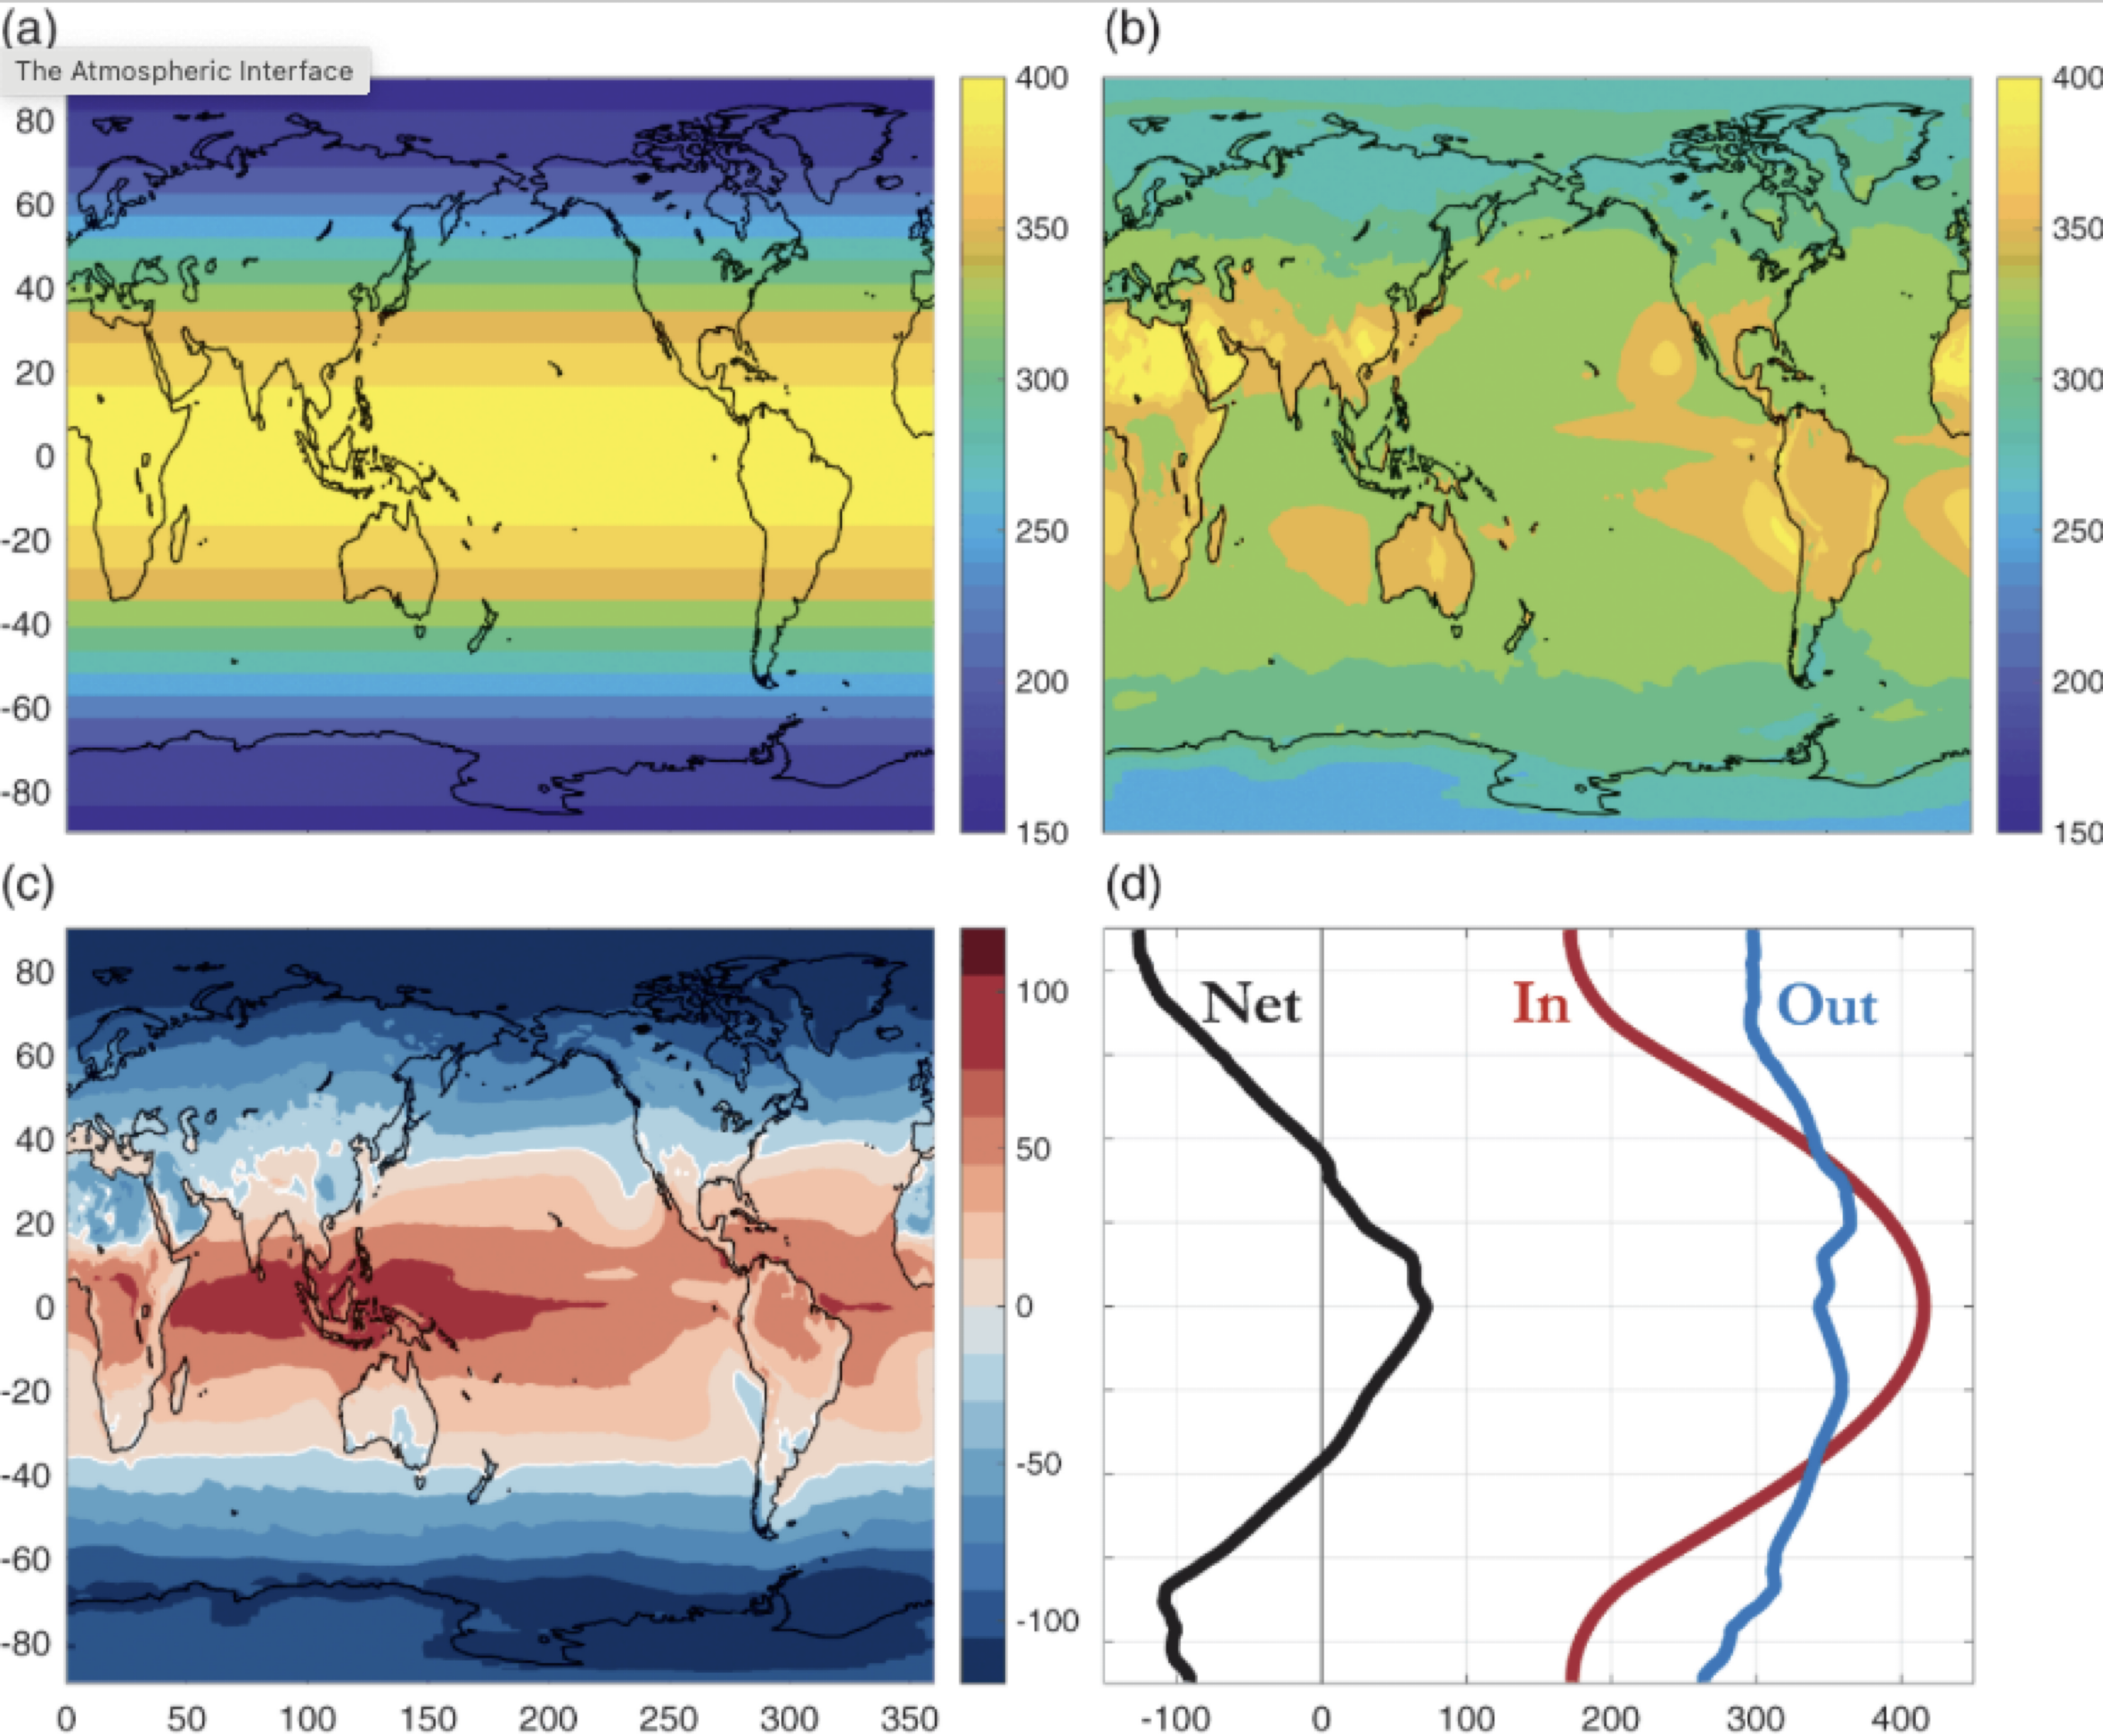
</div>

Figure 1. Long-term mean energy fluxes at the top of the atmopshere (TOA) averaged from July 2005 through June 2015 (W/m$^2$). (a) Incoming shortwave radiation. (b) Outgoing radiation (reflected solar and longwave). (c) Net radiation (incoming - outgoing). (d). Zonal means of incoming, outgoing and net radiation. *Figure reproduced from Physical Oceanography and Climate by Kris Karnauskas.*

<div>
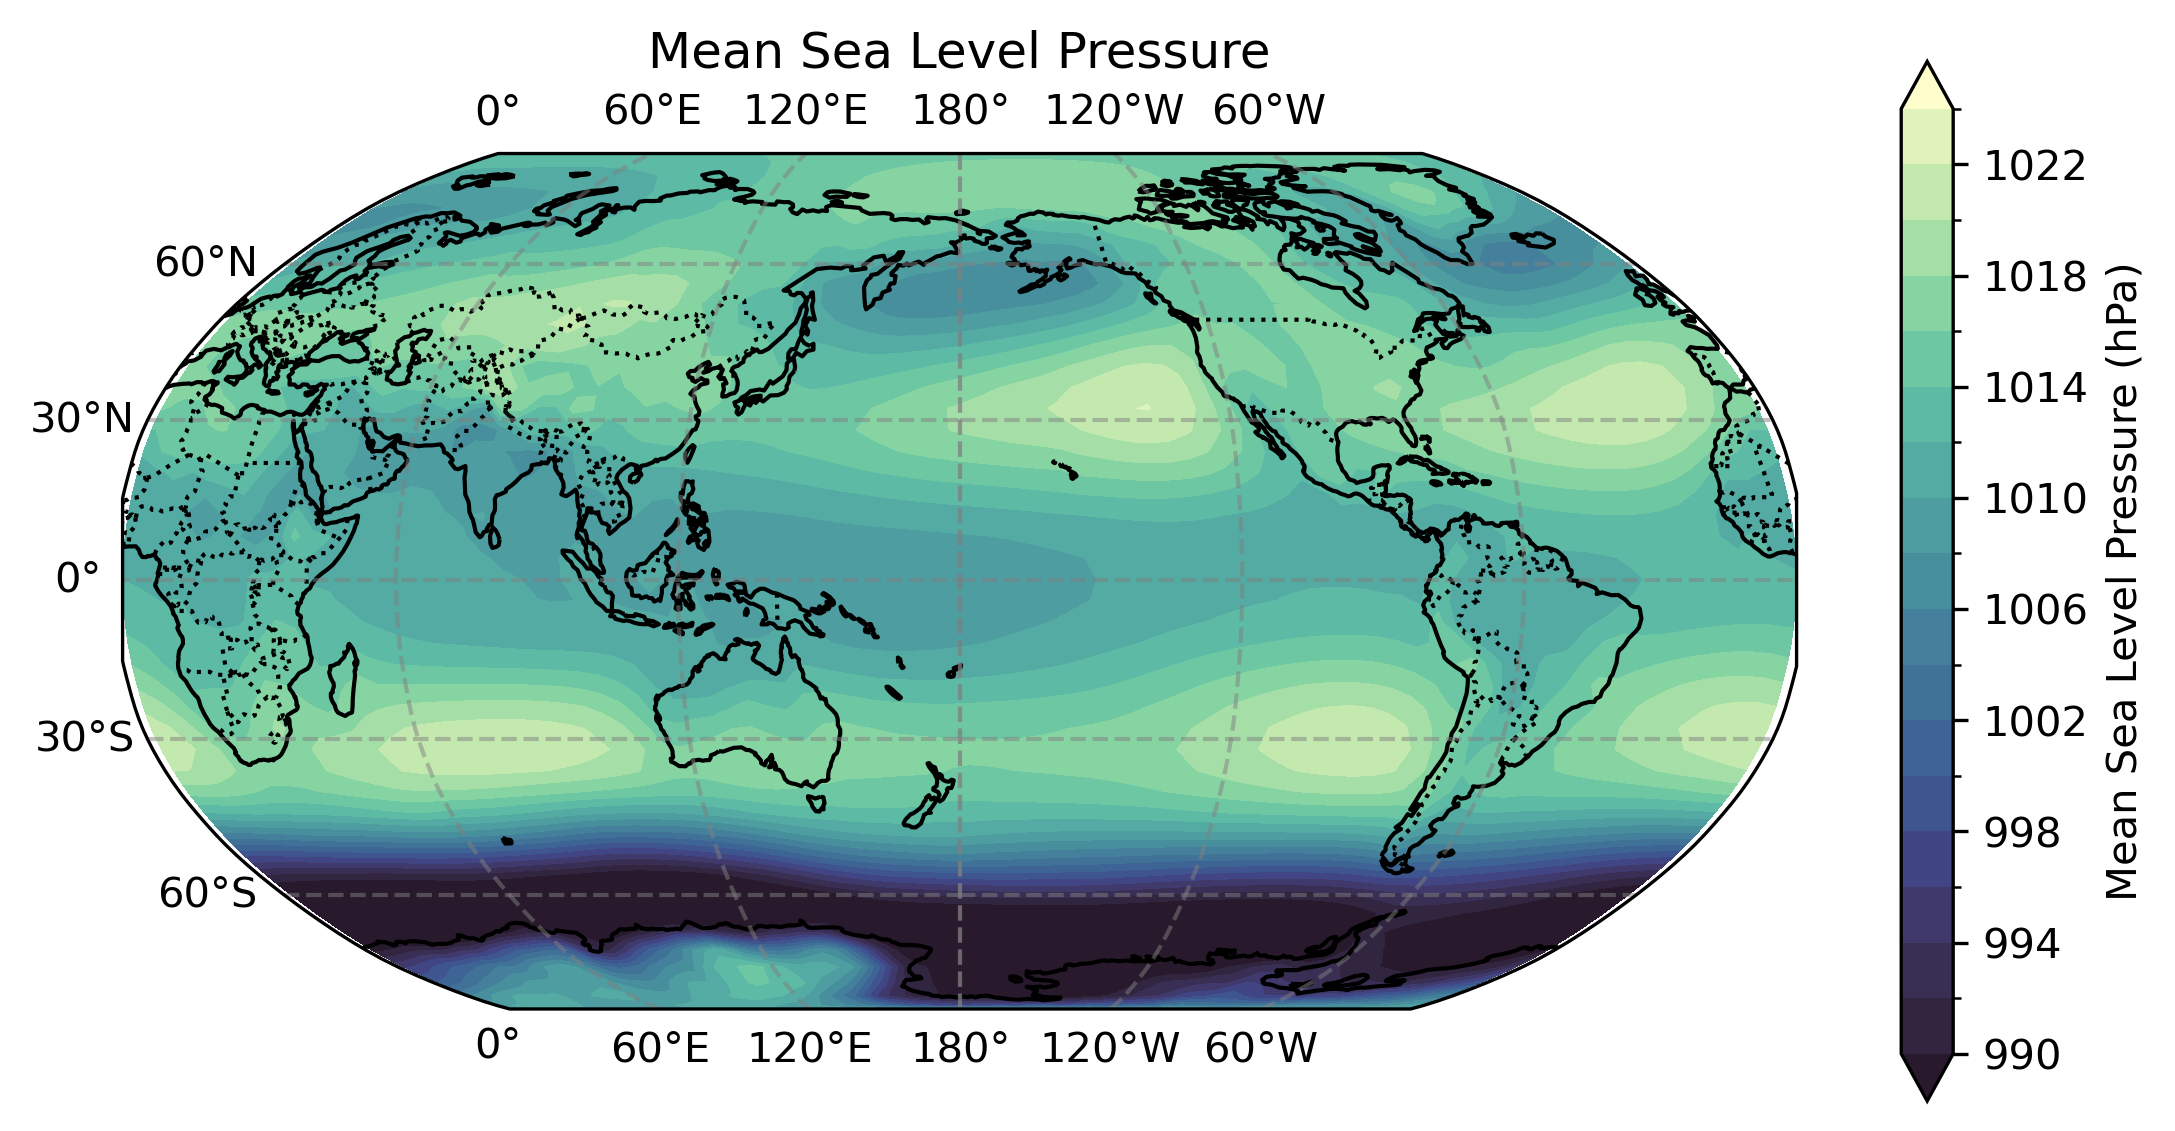
</div>

Figure 2. Annual mean sea-level pressure from July 2005 through June 2015 from the ERA5 renalysis product. *Figure generated by Professor Lawman using Python.*

1. [3pts] The amount of incoming solar radiation at the top of the atmosphere is zonally symmetric *before* any shortwave radiation is reflected or absorbed in the atmosphere or at the surface. Why are the temperature patterns not zonally symmetric at a given latitude? For example over land and along the equator in the Pacific Ocean.

2. [2pts] *Qualitatively*, what is the pressure gradient force (PGF) and how does this influence the wind speed and direction? Why is the PGF considered an acceleration?

3. [2pts] What are the two major factors that influence the magnitude of the wind deflection by the Coriolis effect? How does the Coriolis effect impact the speed of the wind?

4. [4pts] The broadest features of the general circulation of the atmopshere include three circulation cells in each hemisphere. Net radiation at the TOA has strong meridional dependence (Figure 1b). Describe the patterns you observe and comment on how the meridional gradient of net radiation gives rise to the general atmospheric circulation. To receive full credit for the question, you must discuss the fundamental accelerations that drive global wind patterns. Please feel free to include annotated sketches if this will be helpful.

5. [2pts] Building off your answer for Q4, why do we call the polar and Hadley cells **thermally direct**? 

6. [3pts] Identify the North Pacific Subtropical High in Figure 2. This is an example of a semi-permanent high pressure system. Why do subtropical high-pressure systems form and why are they more pronounced over the ocean compared to land? *Quantitatively*, is the meridional pressure gradient force (-$\frac{1}{\rho}\frac{\partial p}{\partial y}$) stronger between (a) the equator and the North Pacific subtropical high, or (b) between the North Pacific subtropical high and the Gulf of Alaska? Provide an approi numerical estimate for the magnitude of the PGF based on the values you read off the sea-level pressure map. Assume the average density of air is 1.3 kg/m$^3$. Are your results consistent with the map of average wind speed you generated for this lab?

8. [4pts] Use the provided global maps of the time-mean sea level pressure (SLP) and outgoing longwave radiation (OLR) as well as the time-mean temperature and wind maps you generated for this lab. (a) Qualitatively describe the Walker circulation in terms of the spatial distribution of SLP, OLR, and horizontal winds in the tropics. (b) Offer a physical explanation for why, especially in the tropics, OLR is observed to be low wherever SLP is also low. (c) Select two locations somewhere in the world ocean – one in the tropics and one in the higher latitudes. How do OLR and SLP covary over time at these two locations? How does this temporal relationship between SLP and OLR differ between tropical and higher-latitude regions? Can you offer an explanation? 

<div>
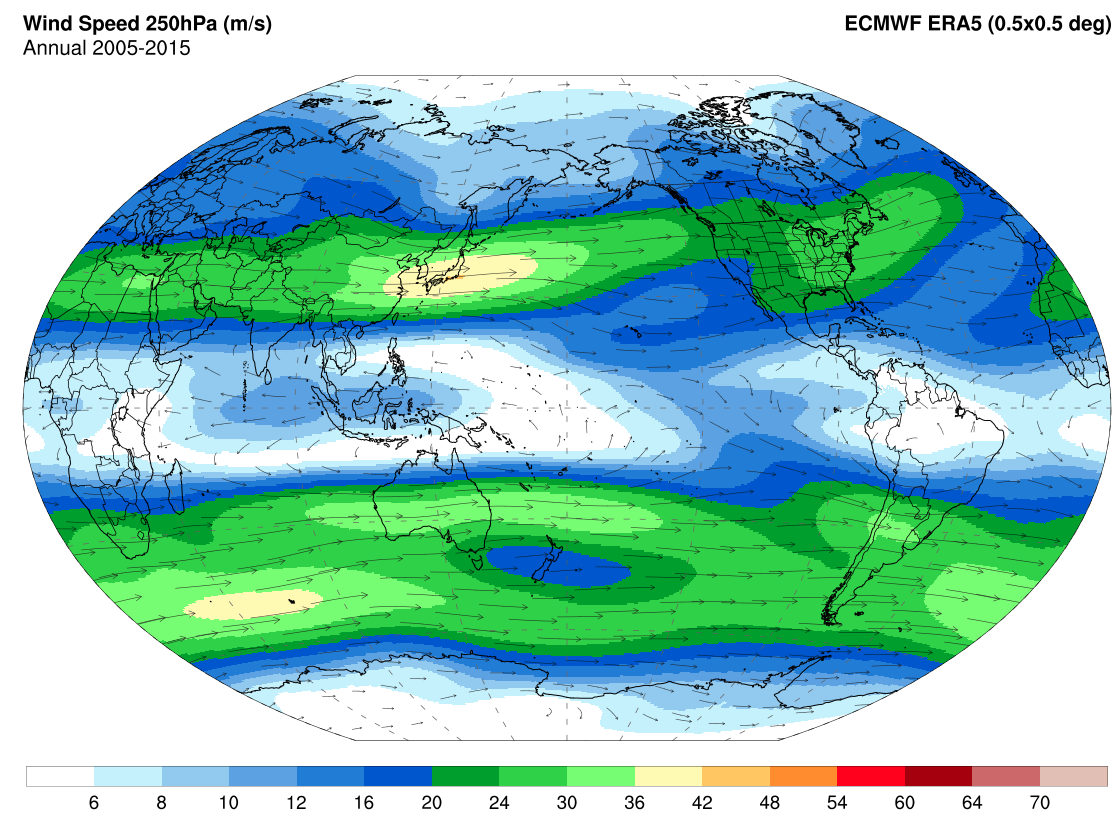
</div>

Figure 3. Annual mean 250 hPa wind speed (units: m/s) from the ERA5 atmospheric reanalysis product (2005-2015). *Figure generated using the [Climate Reanalyzer](https://climatereanalyzer.org/research_tools/monthly_maps/).*

9. [3pts] Figure 3  shows a map of annual average wind speed at 250 hPa (source: The Climate Reanayzer). Note the band of fast, westerly winds in the Southern Hemisphere. How do these winds broadly demonstrate the concept of geostrophic balance?

10. [2pts] How does surface level convergence and divergence influence vertical winds (not plotted in this lab, but discussed in class)? How do the vertical winds associated with uplift and subsidence impact atmospheric pressure at both the surface and in the upper troposphere? How does uplift and subsidence influence total cloud cover and why? To receive full credit, please incorporate your knowledge of atmospheric thermodynamics and stability from Week 1.  

15. [2pts] Why do the tropical rainbelts over the ocean change seasonally throughout the year? How does precipitation vary seasonally in areas with a monsoon climate (e.g., India, East Asia, West Africa, Australia). How does highly seasonal precipitation impact the people that live in these areas? 

16. [1pt] Explain the pattern of warming observed during the past 20-years (2003-2022) compared to the 1961-1980 reference interval. Which areas are warming the most? Why?

---
## Congratulations! You completed Lab 2. 

**Submission instructions:**

1. Re-run the whole Notebook and check there are no errors
4. Submit your Jupyter Notebook (LastName_FirstName_EV333_Lab2.ipynb) on Canvas (1 submission per person).
5. Compile your group's written responses and all the figures you generated in a separate Word or Google document. Export the document as a PDF and upload it to Canvas (1 submission per group).